# Picking the first two bus routes

The official static GTFS download is unavailable, so I am using the Kaggle schedule only as an old route and stop reference. I rank routes from the snapshots collected so far, require both directions in the live and static data, and do not use the old trip IDs or timetable as current truth.

In [1]:
import csv
import re
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

from google.transit import gtfs_realtime_pb2

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
STATIC_PATH = ROOT / "data/external/kaggle_delhi_bus_transit_data/full_bus_schedule.csv"
SNAPSHOT_DIR = ROOT / "data/raw/vehicle_positions_pb"
SELECTED_PATH = ROOT / "data/interim/selected_route_schedule.csv"

snapshots = sorted(SNAPSHOT_DIR.rglob("*.pb"))
assert snapshots, "No protobuf snapshots found"

live = defaultdict(lambda: {
    "observations": 0,
    "vehicles": set(),
    "trips": set(),
    "active_snapshots": 0,
    "first_seen": None,
    "last_seen": None,
})

for path in snapshots:
    timestamp = datetime.strptime(path.stem, "%Y-%m-%dT%H-%M-%S.%fZ")
    feed = gtfs_realtime_pb2.FeedMessage()
    feed.ParseFromString(path.read_bytes())
    seen_routes = set()
    for entity in feed.entity:
        if not entity.HasField("vehicle") or not entity.vehicle.trip.route_id:
            continue
        vehicle = entity.vehicle
        route_id = vehicle.trip.route_id
        stats = live[route_id]
        stats["observations"] += 1
        stats["first_seen"] = min(stats["first_seen"] or timestamp, timestamp)
        stats["last_seen"] = max(stats["last_seen"] or timestamp, timestamp)
        seen_routes.add(route_id)
        if vehicle.vehicle.id:
            stats["vehicles"].add(vehicle.vehicle.id)
        if vehicle.trip.trip_id:
            stats["trips"].add(vehicle.trip.trip_id)
    for route_id in seen_routes:
        live[route_id]["active_snapshots"] += 1

print(f"Loaded {len(snapshots):,} snapshots with {len(live):,} live route IDs.")

Loaded 772 snapshots with 1,928 live route IDs.


In [2]:
route_names = {}
route_stops = defaultdict(set)
route_coordinates = defaultdict(dict)

with STATIC_PATH.open(newline="", encoding="utf-8-sig") as file:
    for row in csv.DictReader(file):
        route_id = row["route_id"]
        if route_id not in live:
            continue
        if row["route_long_name"]:
            route_names[route_id] = row["route_long_name"].strip()
        stop_id = row["stop_id"]
        route_stops[route_id].add(stop_id)
        if row["stop_lat"] and row["stop_lon"]:
            route_coordinates[route_id][stop_id] = (
                float(row["stop_lat"]),
                float(row["stop_lon"]),
            )

families = defaultdict(lambda: defaultdict(list))
for route_id, name in route_names.items():
    match = re.match(r"^(.*?)(UP|DOWN)$", name, re.IGNORECASE)
    if match:
        families[match.group(1).upper()][match.group(2).upper()].append(route_id)

candidates = []
for route, directions in families.items():
    if not directions["UP"] or not directions["DOWN"]:
        continue
    up_id = max(directions["UP"], key=lambda route_id: live[route_id]["observations"])
    down_id = max(directions["DOWN"], key=lambda route_id: live[route_id]["observations"])
    route_ids = (up_id, down_id)
    if min(len(route_stops[route_id]) for route_id in route_ids) < 10:
        continue
    if any(len(route_coordinates[route_id]) != len(route_stops[route_id]) for route_id in route_ids):
        continue
    points = [
        point
        for route_id in route_ids
        for point in route_coordinates[route_id].values()
    ]
    candidates.append({
        "route": route,
        "up_id": up_id,
        "down_id": down_id,
        "observations": sum(live[route_id]["observations"] for route_id in route_ids),
        "up_observations": live[up_id]["observations"],
        "down_observations": live[down_id]["observations"],
        "unique_vehicles": len(live[up_id]["vehicles"] | live[down_id]["vehicles"]),
        "up_stops": len(route_stops[up_id]),
        "down_stops": len(route_stops[down_id]),
        "minimum_active_snapshots": min(live[route_id]["active_snapshots"] for route_id in route_ids),
        "centroid_lat": sum(point[0] for point in points) / len(points),
        "centroid_lon": sum(point[1] for point in points) / len(points),
    })

candidates.sort(key=lambda row: row["observations"], reverse=True)
assert candidates, "No complete two-direction route families found"

print("Top complete two-direction routes by live observations")
print("route  up_id  down_id  observations  up/down       vehicles  stops up/down  min active")
for row in candidates[:15]:
    print(
        f"{row['route']:<6} {row['up_id']:>5}  {row['down_id']:>7}  "
        f"{row['observations']:>12,}  {row['up_observations']:>4,}/{row['down_observations']:<4,}  "
        f"{row['unique_vehicles']:>8}  {row['up_stops']:>3}/{row['down_stops']:<3}       "
        f"{row['minimum_active_snapshots']:>3}"
    )

Top complete two-direction routes by live observations
route  up_id  down_id  observations  up/down       vehicles  stops up/down  min active
925STL  1615     1152         5,736  4,446/1,290       160   36/36        248
185LINKSTL  1919     1958         5,201  1,373/3,828        82   24/23        301
728A     598     2098         5,062  1,331/3,731        80   48/49        195
741     2074     1496         4,449  3,218/1,231        57   65/66        292
78      1366     1515         4,407   435/3,972        80   28/28        135
354     2114     1707         4,202  1,290/2,912        59   49/49        300
356     1978     1749         4,170  3,485/685         60   62/59        220
243      565      181         4,030  3,752/278         34   63/64        240
978A    2100     2008         3,677    66/3,611        55   34/29         66
336     1829      130         3,524  2,763/761         66   60/56        240
910     1348     2048         3,436   467/2,969        80   38/41         87
83

## The pair I am keeping

I picked Route 724 as the more frequently observed route and Route 931 as the lighter route. Both directions appear consistently, their direction counts are reasonably balanced, and the two routes cover different parts of Delhi. I avoided candidates where one direction dominated almost all observations.

In [3]:
selected = {
    "724": {"UP": "1411", "DOWN": "32"},
    "931": {"UP": "1788", "DOWN": "1881"},
}
selected_ids = {route_id for directions in selected.values() for route_id in directions.values()}
candidate_by_route = {row["route"]: row for row in candidates}
assert set(selected) <= candidate_by_route.keys()

rows_by_trip = defaultdict(list)
selected_rows = 0
SELECTED_PATH.parent.mkdir(parents=True, exist_ok=True)

with STATIC_PATH.open(newline="", encoding="utf-8-sig") as source, SELECTED_PATH.open(
    "w", newline="", encoding="utf-8"
) as destination:
    reader = csv.DictReader(source)
    writer = csv.DictWriter(destination, fieldnames=reader.fieldnames)
    writer.writeheader()
    for row in reader:
        route_id = row["route_id"]
        if route_id not in selected_ids:
            continue
        writer.writerow(row)
        rows_by_trip[(route_id, row["trip_id"])].append(row)
        selected_rows += 1

assert selected_rows > 0 and {route_id for route_id, _ in rows_by_trip} == selected_ids
print(f"Wrote {selected_rows:,} static rows to {SELECTED_PATH.relative_to(ROOT)}")

Wrote 6,407 static rows to data/interim/selected_route_schedule.csv


In [4]:
def time_to_seconds(value):
    hours, minutes, seconds = map(int, value.split(":"))
    return hours * 3600 + minutes * 60 + seconds


def seconds_to_time(value):
    hours, remainder = divmod(value, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


details = {}
for route_id in selected_ids:
    route_trips = {
        trip_id: sorted(rows, key=lambda row: int(float(row["stop_sequence"])))
        for (trip_route_id, trip_id), rows in rows_by_trip.items()
        if trip_route_id == route_id
    }
    patterns = Counter(tuple(row["stop_id"] for row in rows) for rows in route_trips.values())
    dominant_pattern, dominant_count = patterns.most_common(1)[0]
    representative = next(
        rows
        for rows in route_trips.values()
        if tuple(row["stop_id"] for row in rows) == dominant_pattern
    )
    valid_sequences = sum(
        [int(float(row["stop_sequence"])) for row in rows] == list(range(len(rows)))
        and all(row["stop_id"] and row["stop_lat"] and row["stop_lon"] for row in rows)
        for rows in route_trips.values()
    )
    departures = [
        time_to_seconds(row["departure_time"])
        for rows in route_trips.values()
        for row in rows
        if row["departure_time"]
    ]
    details[route_id] = {
        "trip_count": len(route_trips),
        "unique_stops": len({row["stop_id"] for rows in route_trips.values() for row in rows}),
        "dominant_stops": len(dominant_pattern),
        "dominant_share": dominant_count / len(route_trips),
        "valid_sequences": valid_sequences,
        "service_start": min(departures),
        "service_end": max(departures),
        "representative": representative,
    }
    assert valid_sequences == len(route_trips)
    assert len(representative) >= 10

print("Selected route summary")
print("route  direction  route_id  live obs  vehicles  static trips  unique stops  main pattern  schedule span")
for route, directions in selected.items():
    for direction, route_id in directions.items():
        stats = live[route_id]
        static = details[route_id]
        print(
            f"{route:<6} {direction:<9} {route_id:>8}  {stats['observations']:>8,}  "
            f"{len(stats['vehicles']):>8}  {static['trip_count']:>12}  "
            f"{static['unique_stops']:>12}  {static['dominant_stops']:>12}  "
            f"{seconds_to_time(static['service_start'])}-{seconds_to_time(static['service_end'])}"
        )

Selected route summary
route  direction  route_id  live obs  vehicles  static trips  unique stops  main pattern  schedule span
724    UP            1411     2,105        26            70            44            44  06:13:00-23:27:01
724    DOWN            32     1,269        20            19            45            45  07:36:00-21:04:58
931    UP            1788     1,210        26            24            38            38  06:11:00-19:00:19
931    DOWN          1881       962        12            40            39            39  05:36:00-22:50:46


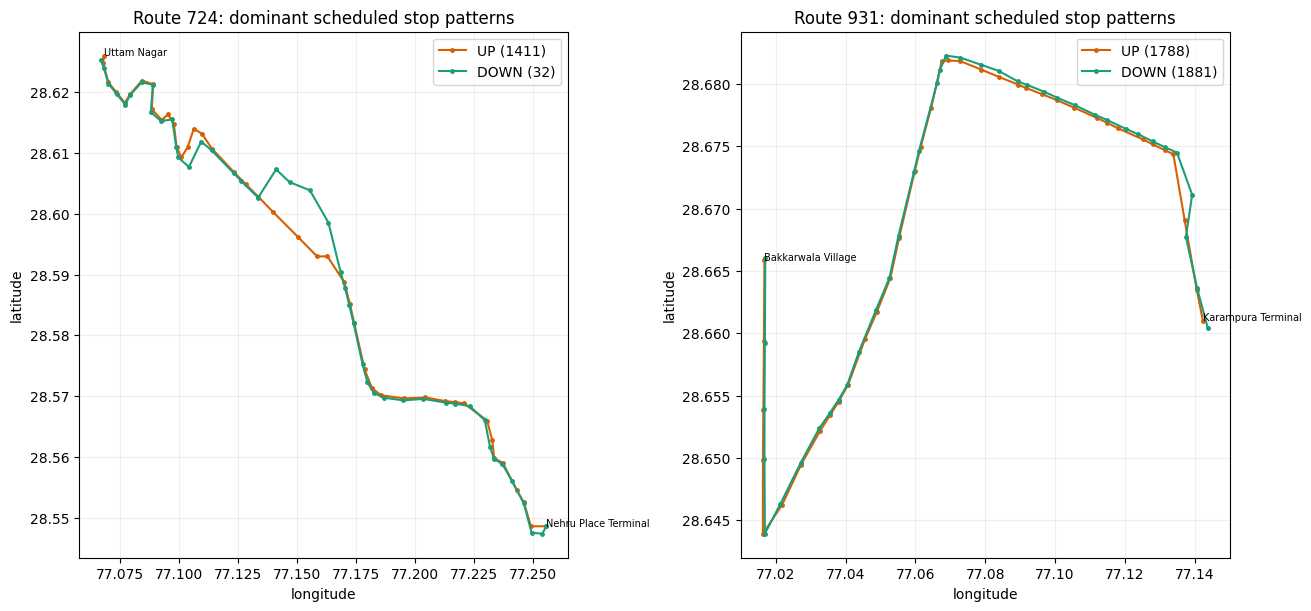

Saved plot to artifacts/route_selection.png


In [5]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
colors = {"UP": "#d95f02", "DOWN": "#1b9e77"}

for axis, (route, directions) in zip(axes, selected.items()):
    for direction, route_id in directions.items():
        rows = details[route_id]["representative"]
        longitude = [float(row["stop_lon"]) for row in rows]
        latitude = [float(row["stop_lat"]) for row in rows]
        axis.plot(longitude, latitude, marker="o", markersize=2.5, linewidth=1.5,
                  color=colors[direction], label=f"{direction} ({route_id})")
        if direction == "UP":
            axis.annotate(rows[0]["stop_name"], (longitude[0], latitude[0]), fontsize=7)
            axis.annotate(rows[-1]["stop_name"], (longitude[-1], latitude[-1]), fontsize=7)
    axis.set_title(f"Route {route}: dominant scheduled stop patterns")
    axis.set_xlabel("longitude")
    axis.set_ylabel("latitude")
    axis.grid(alpha=0.2)
    axis.legend()

artifact_path = ROOT / "artifacts/route_selection.png"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(artifact_path, dpi=160)
plt.show()
print(f"Saved plot to {artifact_path.relative_to(ROOT)}")

## Static columns and missing values

The Kaggle file is already a denormalized join of stops, stop times, trips, routes, agency, and calendar data. The columns I need are:

| Column | Use in this project |
| --- | --- |
| `route_id` | Internal direction-specific ID that also appears in the live feed |
| `route_long_name` | Public route label with `UP` or `DOWN` direction |
| `trip_id` | Old scheduled trip identifier, used only to group stop sequences |
| `stop_id`, `stop_code`, `stop_name` | Stop identity and readable label |
| `stop_lat`, `stop_lon` | Coordinates for mapping and arrival reconstruction |
| `stop_sequence` | Ordered position of a stop within a scheduled trip |
| `arrival_time`, `departure_time` | Old scheduled times used only for rough service coverage |
| `start_date`, `end_date`, weekday flags | Validity period of the old schedule |

In [6]:
with SELECTED_PATH.open(newline="", encoding="utf-8") as file:
    reader = csv.DictReader(file)
    fields = reader.fieldnames
    static_rows = list(reader)

missing = {
    column: sum(not row[column].strip() for row in static_rows)
    for column in fields
}

print(f"Selected static rows: {len(static_rows):,}")
print("column               missing      percent")
for column in fields:
    print(f"{column:<20} {missing[column]:>7,}      {missing[column] / len(static_rows):>6.1%}")

assert missing["shape_id"] == len(static_rows)
assert missing["route_short_name"] == len(static_rows)
assert all(
    count == 0
    for column, count in missing.items()
    if column not in {"shape_id", "route_short_name"}
)

Selected static rows: 6,407
column               missing      percent
trip_id                    0        0.0%
arrival_time               0        0.0%
departure_time             0        0.0%
stop_id                    0        0.0%
stop_sequence              0        0.0%
stop_code                  0        0.0%
stop_lat                   0        0.0%
stop_lon                   0        0.0%
stop_name                  0        0.0%
zone_id                    0        0.0%
route_id                   0        0.0%
service_id                 0        0.0%
shape_id               6,407      100.0%
agency_id                  0        0.0%
route_long_name            0        0.0%
route_short_name       6,407      100.0%
route_type                 0        0.0%
start_date                 0        0.0%
end_date                   0        0.0%
monday                     0        0.0%
tuesday                    0        0.0%
wednesday                  0        0.0%
thursday                   0

Scheduled trips in the old extract: 153
hour  724 UP  724 DOWN  931 UP  931 DOWN
05:00         0         0         0         1
06:00         1         0         2         1
07:00         2         1         4         4
08:00         5         1         2         5
09:00         3         2         4         3
10:00         1         2         0         0
11:00         4         2         0         2
12:00         3         1         0         2
13:00         6         1         0         3
14:00         4         0         3         2
15:00         8         1         3         4
16:00         7         1         3         4
17:00         7         3         3         3
18:00         6         2         0         0
19:00         7         2         0         2
20:00         3         0         0         2
21:00         3         0         0         2


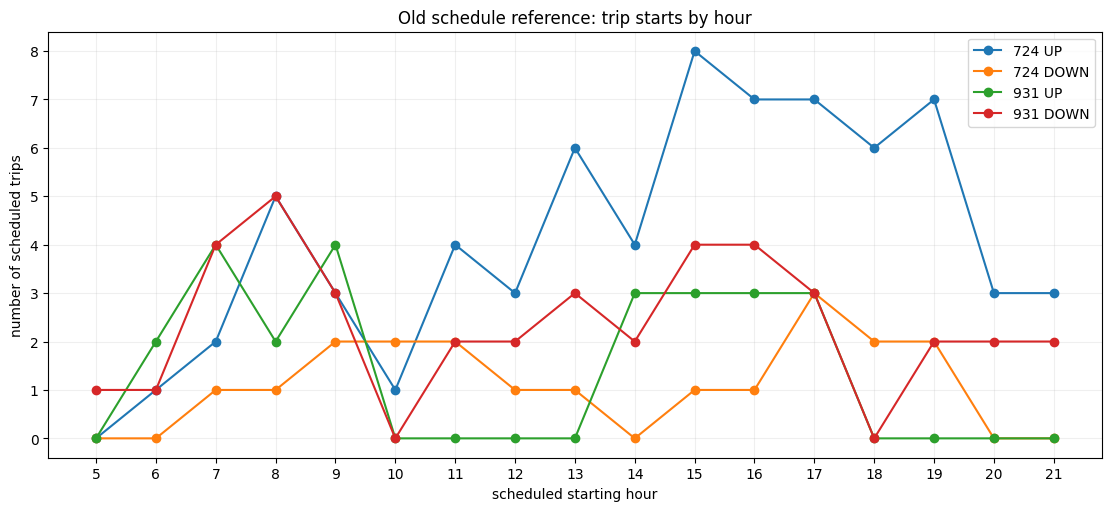

Saved plot to artifacts/scheduled_trip_starts_by_hour.png


In [7]:
route_labels = {
    route_id: (route, direction)
    for route, directions in selected.items()
    for direction, route_id in directions.items()
}
trip_starts = {}
for row in static_rows:
    key = (row["route_id"], row["trip_id"])
    stop_sequence = int(float(row["stop_sequence"]))
    if key not in trip_starts or stop_sequence < trip_starts[key][0]:
        trip_starts[key] = (stop_sequence, row["departure_time"])

hourly_starts = Counter(
    (route_id, time_to_seconds(departure_time) // 3600)
    for (route_id, _), (_, departure_time) in trip_starts.items()
)
hours = range(
    min(hour for _, hour in hourly_starts),
    max(hour for _, hour in hourly_starts) + 1,
)

print(f"Scheduled trips in the old extract: {len(trip_starts):,}")
print("hour  724 UP  724 DOWN  931 UP  931 DOWN")
ordered_ids = ["1411", "32", "1788", "1881"]
for hour in hours:
    counts = [hourly_starts[route_id, hour] for route_id in ordered_ids]
    print(f"{hour:02d}:00  " + "  ".join(f"{count:>8}" for count in counts))

figure, axis = plt.subplots(figsize=(11, 5), constrained_layout=True)
for route_id in ordered_ids:
    route, direction = route_labels[route_id]
    axis.plot(
        list(hours),
        [hourly_starts[route_id, hour] for hour in hours],
        marker="o",
        label=f"{route} {direction}",
    )
axis.set_title("Old schedule reference: trip starts by hour")
axis.set_xlabel("scheduled starting hour")
axis.set_ylabel("number of scheduled trips")
axis.set_xticks(list(hours))
axis.grid(alpha=0.2)
axis.legend()

hourly_plot_path = ROOT / "artifacts/scheduled_trip_starts_by_hour.png"
figure.savefig(hourly_plot_path, dpi=160)
plt.show()
print(f"Saved plot to {hourly_plot_path.relative_to(ROOT)}")

## Selected-route findings

The selected extract has 6,407 stop-time rows covering 153 old scheduled trips. Only `shape_id` and `route_short_name` are empty; every field used for route structure is complete. The useful public route label is stored in `route_long_name`.

Route 724 has 89 scheduled trips in this file and Route 931 has 64. The direction counts are uneven, especially for Route 724, and the calendar ended in 2024. I will not use these counts as claims about current service frequency.

## What I will trust

I will use these static rows for stop order, names, and coordinates. I will use the live protobuf snapshots for vehicle activity and observed timing. The old scheduled times are useful only as a rough service-span reference, and exact static `trip_id` joins are excluded because only about 1% matched the current feed.